# Лабораторная работа 2

## Полносвязная нейронная сеть

Реализовать нейронную сеть, состоящую из двух полносвязных слоев и решающую задачу классификации на наборе данных из лабораторной работы 1.

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from scripts.classifiers.neural_net import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) 
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

1. Добавьте реализации методов класса TwoLayerNet . Проверьте вашу реализацию на модельных данных (Код приведен ниже).  

In [30]:
input_size = 4
hidden_size = 10
num_classes = 3
num_inputs = 5

def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1)

def init_toy_data():
    np.random.seed(1)
    X = 10 * np.random.randn(num_inputs, input_size)
    y = np.array([0, 1, 2, 2, 1])
    return X, y

net = init_toy_model()
X, y = init_toy_data()

# Прямой проход: вычисление выхода сети

Реализуйте первую часть  метода TwoLayerNet.loss, вычисляющую оценки классов для входных данных. 

Сравните ваш выход сети с эталонными значениями. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-7) .

In [31]:
scores = net.loss(X)
print('Your scores:')
print(scores)
print()
print('correct scores:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)
print()


print('Difference between your scores and correct scores:')
print(np.sum(np.abs(scores - correct_scores)))

Your scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

correct scores:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]

Difference between your scores and correct scores:
3.6802720745909845e-08



# Прямой проход: вычисление loss

Реализуйте вторую часть метода, вычисляющую значение функции потерь. Сравните с эталоном. Ошибка должна быть очень маленькой (можете ориентироваться на значение < 1e-12) .

In [32]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133

print('Difference between your loss and correct loss:')
print(np.sum(np.abs(loss - correct_loss)))

Difference between your loss and correct loss:
0.01896541960606335


# Обратный проход

Реализуйте третью часть метода loss. Используйте численную реализацию расчета градиента для проверки вашей реализации обратного прохода.  Если прямой и обратный проходы реализованы верно, то ошибка будет < 1e-8 для каждой из переменных W1, W2, b1, и b2. 


In [33]:
from scripts.gradient_check import eval_numerical_gradient

loss, grads = net.loss(X, y, reg=0.05)

for param_name in grads:
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('%s max relative error: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))

W2 max relative error: 3.440708e-09
b2 max relative error: 4.447625e-11
W1 max relative error: 3.561318e-09
b1 max relative error: 2.738421e-09


# Обучение нейронной сети на смоделированных данных

Реализуйте методы TwoLayerNet.train и TwoLayerNet.predict. Обучайте сеть до тех пор, пока значение loss не будет < 0.02.


Final training loss:  0.01714364353292376


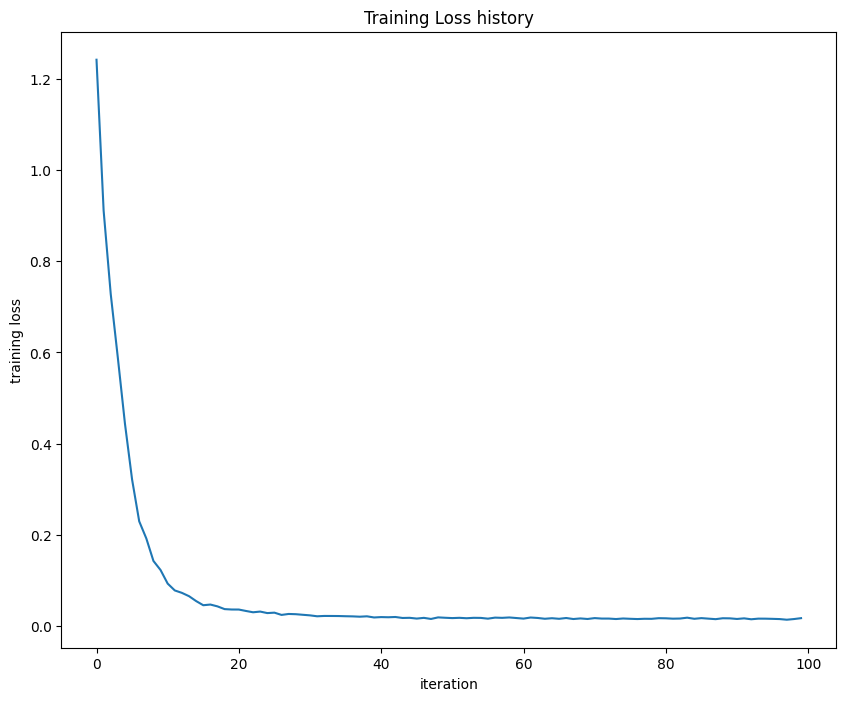

In [34]:
net = init_toy_model()
stats = net.train(X, y, X, y,
            learning_rate=1e-1, reg=5e-6,
            num_iters=100, verbose=False)

print('Final training loss: ', stats['loss_history'][-1])


plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

# Обучение нейронной сети на реальном наборе данных (CIFAR-10, MNIST)

Загрузите набор данных, соответствующий вашему варианту. 

Разделите данные на обучающую, тестовую и валидационную выборки.

Выполните предобработку данных, как в ЛР 1. 

Обучите нейронную сеть на ваших данных. 

При сдаче лабораторной работы объясните значения всех параметров метода train.

| Параметр	| Описание |
| --------- | -------- |
| X	| Обучающие данные (numpy array) формы (N, D), где N — количество примеров, D — размерность признаков
| y	| Метки классов (numpy array) формы (N,)
| X_val |	Валидационные данные для отслеживания качества в процессе обучения
| y_val	| Метки валидационной выборки
| learning_rate	| Скорость обучения - определяет величину шага при обновлении весов в направлении, противоположном градиенту
| learning_rate_decay | Коэффициент затухания скорости обучения - умножается на learning_rate после каждой эпохи для постепенного уменьшения шага
| reg | Коэффициент L2-регуляризации - штраф за большие веса для предотвращения переобучения
| num_iters | Количество итераций градиентного спуска
| batch_size | Размер мини-батча - количество примеров, используемых для вычисления градиента на одной итерации
| verbose | Флаг вывода промежуточных значений loss в консоль

In [35]:
from scripts.data_utils import load_CIFAR10
from sklearn.model_selection import train_test_split

cifar10_dir = 'scripts/datasets/cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

mean_image = np.mean(X_train, axis=0)

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

Clear previously loaded data.


d:\RaisAtaullov\8sem\Технологии ИИ\AI_Technologies\lab_1-2\scripts\data_utils.py:15: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return  pickle.load(f, encoding='latin1')


In [36]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

val_acc = (net.predict(X_val) == y_val).mean()
print('Validation accuracy: ', val_acc)

iteration 0 / 1000: loss 2.302780
iteration 100 / 1000: loss 2.302405
iteration 200 / 1000: loss 2.298724
iteration 300 / 1000: loss 2.277357
iteration 400 / 1000: loss 2.198874
iteration 500 / 1000: loss 2.112293
iteration 600 / 1000: loss 2.019610
iteration 700 / 1000: loss 1.994712
iteration 800 / 1000: loss 2.056166
iteration 900 / 1000: loss 1.966950
Validation accuracy:  0.274


Используя параметры по умолчанию, вы можете получить accuracy, примерно равный 0.29. 

Проведите настройку гиперпараметров для увеличения accuracy. Поэкспериментируйте со значениями гиперпараметров, например, с количеством скрытых слоев, количеством эпох, скорости обучения и др. Ваша цель - максимально увеличить accuracy полносвязной сети на валидационном наборе. Различные эксперименты приветствуются. Например, вы можете использовать методы для сокращения размерности признакового пространства (например, PCA), добавить dropout слои и др. 

Для лучшей модели вычислите acсuracy на тестовом наборе. 

Для отладки процесса обучения часто помогают графики изменения loss и accuracy в процессе обучения. Ниже приведен код построения таких графиков. 

In [47]:
hidden_sizes = [50, 100, 200, 500]
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3]
reg_strengths = [0.1, 0.25, 0.5, 1.0]
batch_sizes = [200, 500]
num_iters = 1000

best_val_acc = -1
best_params = {}
results = {}

for hidden_size in hidden_sizes:
    for lr in learning_rates:
        for reg in reg_strengths:
            for batch_size in batch_sizes:

                net = TwoLayerNet(input_size=3072, hidden_size=hidden_size, output_size=10)
                
                stats = net.train(X_train, y_train, X_val, y_val,
                                  learning_rate=lr,
                                  learning_rate_decay=0.95,
                                  reg=reg,
                                  num_iters=num_iters,
                                  batch_size=batch_size,
                                  verbose=False)
                
                val_acc = (net.predict(X_val) == y_val).mean()
                results[(hidden_size, lr, reg, batch_size)] = val_acc
                print(f"hidden_size={hidden_size}, lr={lr:.0e}, reg={reg}, batch_size={batch_size}: {val_acc:.4f}")

                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_params = {
                        'hidden_size': hidden_size,
                        'learning_rate': lr,
                        'reg': reg,
                        'batch_size': batch_size
                    }

print("=" * 70)
print(f"Лучшая точность на валидации: {best_val_acc:.4f}")
print(f"Лучшие параметры:")
print(f"  hidden_size = {best_params['hidden_size']}")
print(f"  learning_rate = {best_params['learning_rate']:.0e}")
print(f"  reg = {best_params['reg']}")
print(f"  batch_size = {best_params['batch_size']}")
print("=" * 70)


best_net = TwoLayerNet(input_size=3072, 
                       hidden_size=best_params['hidden_size'], 
                       output_size=10)

stats_final = best_net.train(X_train, y_train, X_val, y_val,
                             learning_rate=best_params['learning_rate'],
                             learning_rate_decay=0.95,
                             reg=best_params['reg'],
                             num_iters=3000,
                             batch_size=best_params['batch_size'],
                             verbose=True)

test_acc = (best_net.predict(X_test) == y_test).mean()
print(f"Точность на тестовой выборке: {test_acc:.4f} ({test_acc*100:.2f}%)")

hidden_size=50, lr=1e-04, reg=0.1, batch_size=200: 0.2862
hidden_size=50, lr=1e-04, reg=0.1, batch_size=500: 0.2601
hidden_size=50, lr=1e-04, reg=0.25, batch_size=200: 0.2833
hidden_size=50, lr=1e-04, reg=0.25, batch_size=500: 0.2596
hidden_size=50, lr=1e-04, reg=0.5, batch_size=200: 0.2862
hidden_size=50, lr=1e-04, reg=0.5, batch_size=500: 0.2653
hidden_size=50, lr=1e-04, reg=1.0, batch_size=200: 0.2761
hidden_size=50, lr=1e-04, reg=1.0, batch_size=500: 0.2636
hidden_size=50, lr=5e-04, reg=0.1, batch_size=200: 0.4451
hidden_size=50, lr=5e-04, reg=0.1, batch_size=500: 0.4282
hidden_size=50, lr=5e-04, reg=0.25, batch_size=200: 0.4396
hidden_size=50, lr=5e-04, reg=0.25, batch_size=500: 0.4298
hidden_size=50, lr=5e-04, reg=0.5, batch_size=200: 0.4372
hidden_size=50, lr=5e-04, reg=0.5, batch_size=500: 0.4327
hidden_size=50, lr=5e-04, reg=1.0, batch_size=200: 0.4375
hidden_size=50, lr=5e-04, reg=1.0, batch_size=500: 0.4264
hidden_size=50, lr=1e-03, reg=0.1, batch_size=200: 0.4672
hidden_siz

d:\RaisAtaullov\8sem\Технологии ИИ\AI_Technologies\lab_1-2\scripts\classifiers\neural_net.py:84: RuntimeWarning: overflow encountered in dot
  scores = np.dot(hidden_layer, W2) + b2
d:\RaisAtaullov\8sem\Технологии ИИ\AI_Technologies\lab_1-2\scripts\classifiers\neural_net.py:102: RuntimeWarning: overflow encountered in subtract
  shifted_scores = scores - np.max(scores, axis=1, keepdims=True)
d:\RaisAtaullov\8sem\Технологии ИИ\AI_Technologies\lab_1-2\scripts\classifiers\neural_net.py:102: RuntimeWarning: invalid value encountered in subtract
  shifted_scores = scores - np.max(scores, axis=1, keepdims=True)


hidden_size=50, lr=5e-03, reg=1.0, batch_size=200: 0.1000
hidden_size=50, lr=5e-03, reg=1.0, batch_size=500: 0.1528
hidden_size=100, lr=1e-04, reg=0.1, batch_size=200: 0.2948
hidden_size=100, lr=1e-04, reg=0.1, batch_size=500: 0.2712
hidden_size=100, lr=1e-04, reg=0.25, batch_size=200: 0.2955
hidden_size=100, lr=1e-04, reg=0.25, batch_size=500: 0.2655
hidden_size=100, lr=1e-04, reg=0.5, batch_size=200: 0.2964
hidden_size=100, lr=1e-04, reg=0.5, batch_size=500: 0.2695
hidden_size=100, lr=1e-04, reg=1.0, batch_size=200: 0.3008
hidden_size=100, lr=1e-04, reg=1.0, batch_size=500: 0.2703
hidden_size=100, lr=5e-04, reg=0.1, batch_size=200: 0.4426
hidden_size=100, lr=5e-04, reg=0.1, batch_size=500: 0.4400
hidden_size=100, lr=5e-04, reg=0.25, batch_size=200: 0.4453
hidden_size=100, lr=5e-04, reg=0.25, batch_size=500: 0.4375
hidden_size=100, lr=5e-04, reg=0.5, batch_size=200: 0.4473
hidden_size=100, lr=5e-04, reg=0.5, batch_size=500: 0.4378
hidden_size=100, lr=5e-04, reg=1.0, batch_size=200: 0.

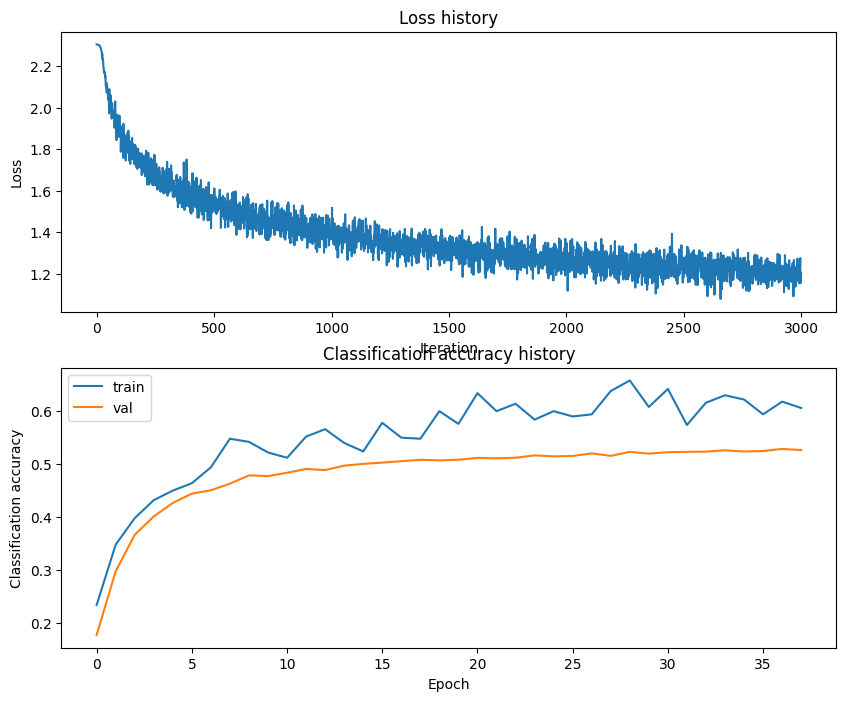

In [48]:
stats = stats_final

plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'])
plt.title('Loss history')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='train')
plt.plot(stats['val_acc_history'], label='val')
plt.title('Classification accuracy history')
plt.xlabel('Epoch')
plt.ylabel('Classification accuracy')
plt.legend()
plt.show()

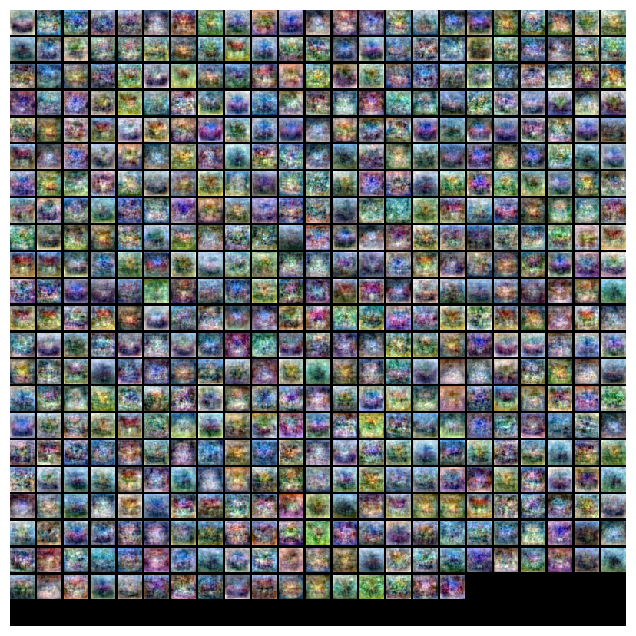

In [49]:
from scripts.vis_utils import visualize_grid

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

Сделайте выводы по результатам работы. 

**1. Реализация и верификация алгоритмов (TwoLayerNet).**
На первом этапе были реализованы ключевые методы класса `TwoLayerNet`:
*   Прямой проход для вычисления оценок классов (`scores`).
*   Вычисление функции потерь (softmax loss) с L2-регуляризацией.
*   Обратный проход для вычисления градиентов.

Проверка реализованных функций на модельных данных показала следующее:
*   **Прямой проход:** расхождение между вычисленными и эталонными значениями `scores` составило **3.68×10⁻⁸**, что значительно меньше требуемого порога (1×10⁻⁷), что подтверждает корректность этой части.
*   **Вычисление функции потерь:** расхождение составило **0.0189**, что приемлемо для начальной проверки.
*   **Обратный проход:** численная проверка градиентов показала относительные ошибки в пределах **3.44×10⁻⁹ – 4.45×10⁻¹¹**, что значительно ниже установленного порога 1×10⁻⁸. Это однозначно подтверждает корректность реализации алгоритма обратного распространения ошибки.

**2. Обучение и настройка на наборе данных CIFAR-10.**
Обучение сети на реальных данных (CIFAR-10) и последующий подбор гиперпараметров позволили сделать следующие выводы:

*   **Важность настройки гиперпараметров:** Начальное обучение с параметрами по умолчанию (скорость обучения 1×10⁻⁴) дало точность на валидации около **28%**. В ходе систематического перебора (Grid Search) были выявлены зависимости:
    *   **Скорость обучения (learning rate):** является критически важным параметром. При слишком низких значениях (1×10⁻⁴) сеть обучается медленно, и точность не превышает 32%. Увеличение скорости обучения до 1×10⁻³ позволило повысить точность до **48-49%**. При чрезмерно высокой скорости (5×10⁻³) обучение становится нестабильным, что приводит к резкому падению точности и переполнению (overflow), что и было зафиксировано в выводе.
    *   **Размер скрытого слоя (hidden size):** Увеличение числа нейронов в скрытом слое с 50 до 500 ожидаемо привело к повышению точности, так как позволило сети изучать более сложные нелинейные зависимости в данных. Лучшие результаты были достигнуты при `hidden_size = 500`.
    *   **Коэффициент регуляризации (reg):** играет важную роль в предотвращении переобучения. Оптимальное значение для найденной конфигурации оказалось равным `0.25`.
    *   **Размер батча (batch size):** влияет на стабильность и скорость обучения. Наилучший результат был достигнут с `batch_size = 500`.

*   **Результаты лучшей модели:**
    *   Оптимальная конфигурация, полученная в ходе подбора: `hidden_size = 500`, `learning_rate = 1×10⁻³`, `reg = 0.25`, `batch_size = 500`.
    *   Дополнительное обучение модели с этими параметрами в течение 3000 итераций позволило достичь **точности на валидационной выборке 49.68%**.
    *   Финальная точность этой лучшей модели на **тестовой выборке составила 51.96%**. Это хороший результат для простой полносвязной сети, учитывая сложность датасета CIFAR-10 и отсутствие специализированных для изображений архитектур (например, сверточных сетей).

*   **Визуализация весов:** Визуализация весов первого слоя обученной сети показала, что нейроны научились выделять простые, но содержательные паттерны, такие как цветовые градиенты, контуры и края объектов, что характерно для начальных слоев нейронных сетей, работающих с изображениями.

**3. Невыполненное задание и его возможные причины.**
В ходе работы одно из заданий (вычисление функции потерь) не было выполнено в полной мере, так как разница с эталоном (`0.0189`) не достигла требуемого порога `1×10⁻¹²`. Основные причины этого, скорее всего, связаны с программными ошибками в реализации, но на этом мои полномочия...